In [5]:
# ============================================================
# AUTOSUPPLY-AI
# BUSINESS INSIGHTS & DECISION SUPPORT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("AUTOSUPPLY-AI BUSINESS INSIGHTS")
print("=" * 70)

# ============================================================
# LOAD FINAL FORECAST DATA
# ============================================================

FORECAST_FILE = "final_demand_forecast.csv"

forecast_df = pd.read_csv(FORECAST_FILE)

# Convert month to datetime
forecast_df["month"] = pd.to_datetime(
    forecast_df["month"],
    errors="coerce"
)

# Convert demand to numeric
forecast_df["predicted_demand"] = pd.to_numeric(
    forecast_df["predicted_demand"],
    errors="coerce"
)

# Remove invalid rows
forecast_df = forecast_df.dropna(
    subset=[
        "month",
        "state",
        "vehicle_group",
        "predicted_demand"
    ]
)

# ============================================================
# BASIC INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("FORECAST DATA LOADED SUCCESSFULLY")
print("=" * 70)

print("\nDataset Shape:")
print(forecast_df.shape)

print("\nColumns:")
print(forecast_df.columns.tolist())

print("\nDate Range:")
print(
    forecast_df["month"].min(),
    "to",
    forecast_df["month"].max()
)

print("\nUnique States:")
print(forecast_df["state"].nunique())

print("\nUnique Vehicle Groups:")
print(forecast_df["vehicle_group"].nunique())

print("\nTotal Forecasted Demand:")
print(
    f"{forecast_df['predicted_demand'].sum():,.2f}"
)

print("\n" + "=" * 70)

AUTOSUPPLY-AI BUSINESS INSIGHTS

FORECAST DATA LOADED SUCCESSFULLY

Dataset Shape:
(1218, 4)

Columns:
['month', 'state', 'vehicle_group', 'predicted_demand']

Date Range:
2024-05-01 00:00:00 to 2024-10-01 00:00:00

Unique States:
34

Unique Vehicle Groups:
6

Total Forecasted Demand:
26,760,503.02



STATE-LEVEL DEMAND ANALYSIS

TOP 10 STATES BY FORECASTED DEMAND
----------------------------------------------------------------------


,state,total_demand,average_demand,maximum_demand,demand_share_pct
0,Rajasthan,13406245.85,372395.72,1774344.12,50.10
1,Uttar Pradesh,2281127.79,63364.66,304449.09,8.52
2,Maharashtra,1267945.83,35220.72,166882.03,4.74
3,Tamil Nadu,1082053.98,30057.05,160157.55,4.04
4,Karnataka,949593.35,26377.59,127970.94,3.55
5,Madhya Pradesh,767727.89,21325.77,110518.82,2.87
6,Bihar,755540.35,20987.23,123031.94,2.82
7,Gujarat,738498.87,20513.86,90308.34,2.76
8,Arunachal Pradesh,607001.91,16861.16,90588.91,2.27
9,West Bengal,599764.59,16660.13,91423.29,2.24



KEY STATE INSIGHTS

Highest Demand State : Rajasthan
Total Demand        : 13,406,245.85
Demand Share        : 50.10%

Lowest Demand State  : Ladakh
Total Demand        : 10,870.91


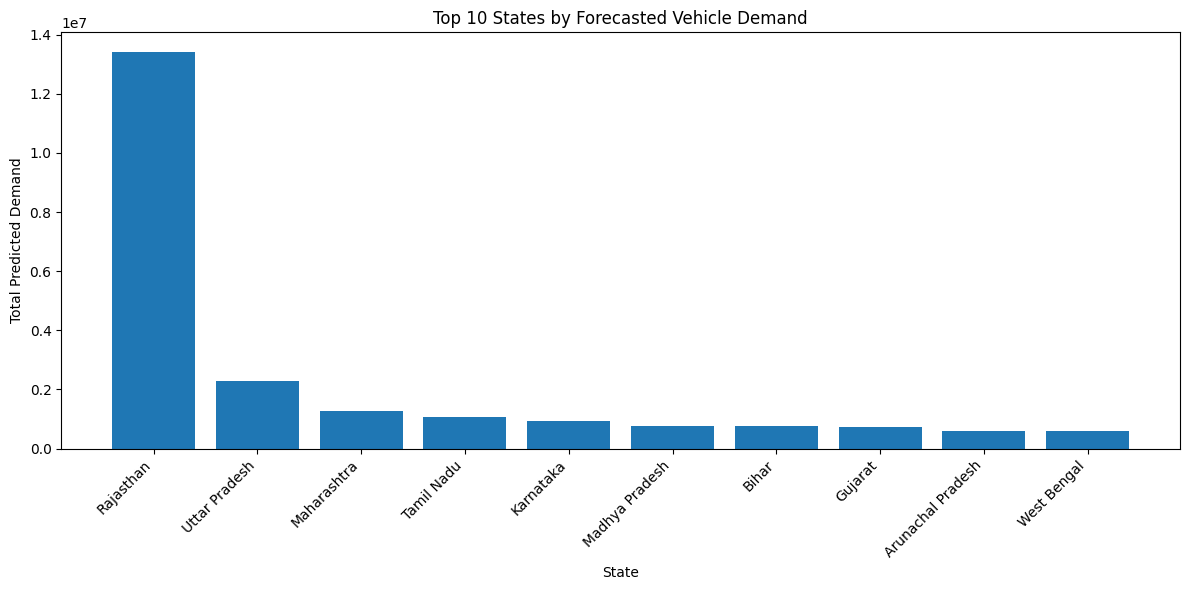

In [6]:
# ============================================================
# CELL 2 — STATE-LEVEL DEMAND ANALYSIS
# ============================================================

print("=" * 70)
print("STATE-LEVEL DEMAND ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# AGGREGATE DEMAND BY STATE
# ------------------------------------------------------------

state_analysis = (
    forecast_df
    .groupby("state")["predicted_demand"]
    .agg(
        total_demand="sum",
        average_demand="mean",
        maximum_demand="max"
    )
    .sort_values("total_demand", ascending=False)
    .reset_index()
)

# ------------------------------------------------------------
# CALCULATE DEMAND SHARE
# ------------------------------------------------------------

total_demand = forecast_df["predicted_demand"].sum()

state_analysis["demand_share_pct"] = (
    state_analysis["total_demand"] / total_demand * 100
)

# ------------------------------------------------------------
# ROUND VALUES
# ------------------------------------------------------------

state_analysis["total_demand"] = state_analysis["total_demand"].round(2)
state_analysis["average_demand"] = state_analysis["average_demand"].round(2)
state_analysis["maximum_demand"] = state_analysis["maximum_demand"].round(2)
state_analysis["demand_share_pct"] = state_analysis["demand_share_pct"].round(2)

# ------------------------------------------------------------
# DISPLAY TOP 10 STATES
# ------------------------------------------------------------

print("\nTOP 10 STATES BY FORECASTED DEMAND")
print("-" * 70)

display(
    state_analysis.head(10)
)

# ------------------------------------------------------------
# KEY STATE INSIGHTS
# ------------------------------------------------------------

top_state = state_analysis.iloc[0]

lowest_state = state_analysis.iloc[-1]

print("\n" + "=" * 70)
print("KEY STATE INSIGHTS")
print("=" * 70)

print(
    f"\nHighest Demand State : {top_state['state']}"
)

print(
    f"Total Demand        : {top_state['total_demand']:,.2f}"
)

print(
    f"Demand Share        : {top_state['demand_share_pct']:.2f}%"
)

print(
    f"\nLowest Demand State  : {lowest_state['state']}"
)

print(
    f"Total Demand        : {lowest_state['total_demand']:,.2f}"
)

# ------------------------------------------------------------
# TOP 10 STATE VISUALIZATION
# ------------------------------------------------------------

top_10_states = state_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_10_states["state"],
    top_10_states["total_demand"]
)

plt.title("Top 10 States by Forecasted Vehicle Demand")

plt.xlabel("State")

plt.ylabel("Total Predicted Demand")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()